<a href="https://colab.research.google.com/github/aminmoosavi/__PyTorch__/blob/main/PyTorch_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Day-5**
**In this notebook we will learn how to implement a convolutional neuroan network for image processing and classification**

* ### Checking the gpu

In [16]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [1]:
import torch
from torch import nn
import numpy as np
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from matplotlib import pyplot as plt
from dataclasses import dataclass

* ### Setting device to gpu if available

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

* # The data
**Here we use the MNIST data (only digits)**

In [36]:
train_data = datasets.EMNIST(
    split= "digits", # <- Looking only at digits
    root="data",
    train = True,
    download= True,
    transform= ToTensor(),
    target_transform= None
    )

# the data set is too big. Let's take only 1 percent of it
num_samples = len(train_data) // 100
train_data.data = train_data.data[:num_samples]
train_data.targets = train_data.targets[:num_samples]


print(len(train_data))


test_data = datasets.EMNIST(
    split= "digits",
    root="data",
    train = False,
    download= True,
    transform= ToTensor(),
    target_transform= None
    )

# the data set is too big. Let's take only 1 percent of it
num_samples = len(test_data) // 40
test_data.data = test_data.data[:num_samples]
test_data.targets = test_data.targets[:num_samples]

print(len(test_data))


2400
1000


* # Visualize the data

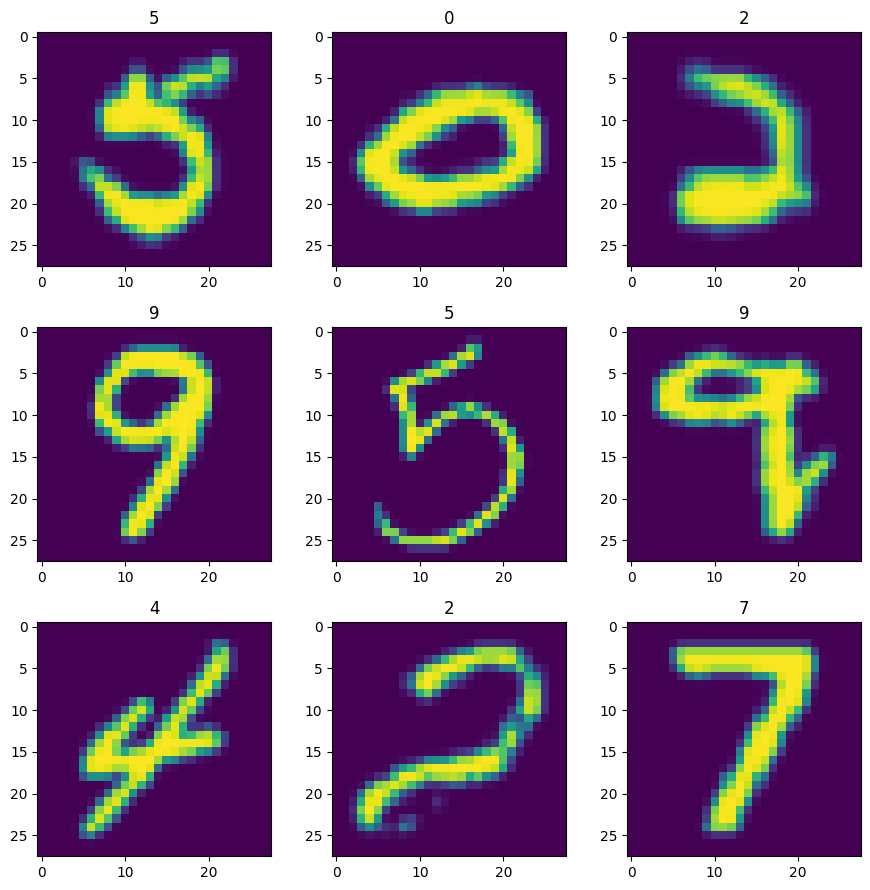

In [20]:
# Look at some images

fig, axs = plt.subplots(3, 3, figsize=(9, 9))
axs = axs.ravel()  # or axs.flatten()

for i in range(9):
  image , label = train_data[
      torch.randint( len(train_data) , size=(1,1) ).item()
      ]
  axs[i].imshow(image.squeeze().T)
  axs[i].set_title(train_data.classes[label])

plt.tight_layout()
plt.show()



* # DataLoader
 **Use `torch.utils.data.DataLoader()` to reorganize the data into batches**

 **DataLoader returns an iterabel data set that allows looping through the batches in the training**

In [46]:
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size= 32,
    shuffle= True
                              )

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size= 32,
    shuffle= True
                              )
train_dataloader.batch_size
test_dataloader.dataset.targets.shape

torch.Size([1000])

In [42]:
print(f"Number of training batches is = {len(train_dataloader)}")
print(f"Number of testing batches is = {len(test_dataloader)}")

Number of training batches is = 75
Number of testing batches is = 1000


* # The Model

* ### Model configuration

 **Because the model is larger than the previous models with more hyperparameters here we set a dataclass for the hyperparameters**

 **See https://poloclub.github.io/cnn-explainer/ for details of the CNN networks**

In [23]:
@dataclass
class Config:
  batch_size: int = 32
  image_channels: int = 3
  image_dim: int = 2
  conv_net_hidden: int = 10
  conv_net_kernel_size: int = 3
  conv_net_stride: int = 1
  conv_net_padding: int = 0
  maxpooling_size: int = 2
  number_of_unique_labels: int = 10

image , label = next(iter(train_dataloader))
imshape = image.shape

number_of_unique_labels = len(train_dataloader.dataset.classes)

# instantiating the config object and overwriting hyperparameters if needed
cfg = Config(batch_size = train_dataloader.batch_size,
             image_channels = imshape[1],
             number_of_unique_labels=len(train_dataloader.dataset.classes)
             )


In [24]:
print(f"Number of image channels = {cfg.image_channels:.0f}")
print(f"Batch size = {cfg.batch_size:.0f}")

Number of image channels = 1
Batch size = 32


* # Building the model
**Here we make two sequential blocks. **
1. **The convolution block composed of two convolution layers each followed by a ReLU nonlinearity and MaxPooling**
* To build a convolution layer we do not pass the size of images directly. Instead, we pass the number of channels (e.g. `in_channels = 1` for grayscale and `in_channels = 3` for RGB colored images. )
* The output channels is  a hyperparameter and can be any number.
* Kernel_size is the size of the filter that is being used to convolve over the image.
* stride is the step sizes in the process of convolution.
* padding adds a frame of zeros of thickness equal to the padding number around the image. It allows the center of the convolution kernel to get closer to the edges of the image.

* Max pooling is a downsampling operation commonly used in convolutional neural networks (CNNs). It reduces the spatial dimensions (height and width) of feature maps while preserving the most important features. A max pooling layer slides a window (e.g., 2×2) over the input feature map and outputs the maximum value within each window. So if input image is 28 by 28 pixels the output will be 14 by 14.

2. **A classification block composed of a flattenning and a linear layer that returns the logits to do classification**
* `nn.Flatten()` flattens all dimensions of its input except the batch (zeroth dimension)
* Input of linear layer equals the total number of output features (not channels) of the Flatten layer. You can calculate it before hand or use a trick.
* The trick is to instantiate a model commenting out the linear layer, then forward passing a batch of data through the model and look at the shape of Flatten layer output.

In [25]:
class CnnImageClassificationModel(nn.Module):
  def __init__(self , cfg: Config): #<- This class takes cfg as input
    super().__init__()
    self.cfg = cfg #<- own cfg if needed to be an attribute of the model
    self.cnn_block = nn.Sequential(
        nn.Conv2d(
            in_channels= cfg.image_channels,
            out_channels= cfg.conv_net_hidden,
            stride= cfg.conv_net_stride,
            padding= cfg.conv_net_padding,
            kernel_size= cfg.conv_net_kernel_size
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=cfg.maxpooling_size),

        nn.Conv2d(
            in_channels= cfg.conv_net_hidden,
            out_channels= cfg.conv_net_hidden,
            stride= cfg.conv_net_stride,
            padding= cfg.conv_net_padding,
            kernel_size= cfg.conv_net_kernel_size
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=cfg.maxpooling_size)
    )

    self.classifier_block = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= 250 , out_features=cfg.number_of_unique_labels)

    )
  def forward(self ,x):
    return self.classifier_block(self.cnn_block(x))




# instantiating the model
model_5 =CnnImageClassificationModel(cfg)

"""
The following is to check the output of the flatten layer.
Before running this comment out the nn.Linear in the classifier_block (Line 28).
When knowing the output features of flatten layer set in_features of the linear
layer. Run again.

"""
model_5.eval()
with torch.inference_mode():
  output1 = model_5(image)
image.shape
output1.shape

torch.Size([32, 10])

* # Loss function

In [26]:
loss_fn = nn.CrossEntropyLoss()

* # Optimizer

In [27]:
optimizer = torch.optim.SGD(params=model_5.parameters(),
                            lr=0.01)

* # The training loop

In [98]:
epochs = 101
losses = torch.zeros(
    size = (epochs ,len(train_dataloader)),
    requires_grad = False ) #<- to keep the loss values

for epoch in range(epochs):


  model_5.train()

  for batch, (X, y) in enumerate(train_dataloader):

    logits = model_5(X)

    loss = loss_fn(logits , y)
    losses[epoch , batch] = loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  if epoch % 10 ==0:
    print(f"epoch={epoch} ---- loss = {losses[epoch,:].mean()}")



epoch=0 ---- loss = 0.002922993851825595
epoch=10 ---- loss = 0.0025975580792874098
epoch=20 ---- loss = 0.0023856323678046465
epoch=30 ---- loss = 0.002150516025722027
epoch=40 ---- loss = 0.001988328294828534
epoch=50 ---- loss = 0.0018375732470303774
epoch=60 ---- loss = 0.0017056729411706328
epoch=70 ---- loss = 0.0015935907140374184
epoch=80 ---- loss = 0.0014921263791620731
epoch=90 ---- loss = 0.0013897247845306993
epoch=100 ---- loss = 0.0013117514317855239


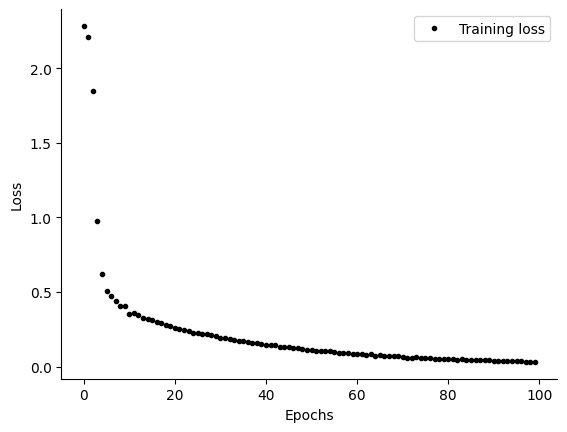

In [29]:
# Casting the loss tensors into NumPy arrays
lossvals=losses.detach().numpy()
# lossvals_test=losses_test.detach().numpy()
lossvals = np.mean(lossvals,axis=1)
# Plotting the loss functions
fig, ax = plt.subplots()
plt.plot(lossvals,'.',color='k',label = 'Training loss')
# ax.plot(lossvals_test,'.',color='r',label = 'Testing loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()


* # Model Evaluation

In [80]:
model_5.eval()
y_pred = torch.zeros((test_dataloader.batch_size , len(test_dataloader)))
y_true = torch.zeros((test_dataloader.batch_size , len(test_dataloader)))

with torch.inference_mode():
  for batch, (X,y) in enumerate(test_dataloader):
    logits = model_5(X)
    y_pred[batch,:logits.size()[0]] = logits.argmax(dim=1)[:]
    y_true[batch,:logits.size()[0]] = y

print(y_pred.shape)
print(y_true.shape)
print(X.shape)

torch.Size([32, 32])
torch.Size([32, 32])
torch.Size([8, 1, 28, 28])


* ### Looking at a few predictions on test data

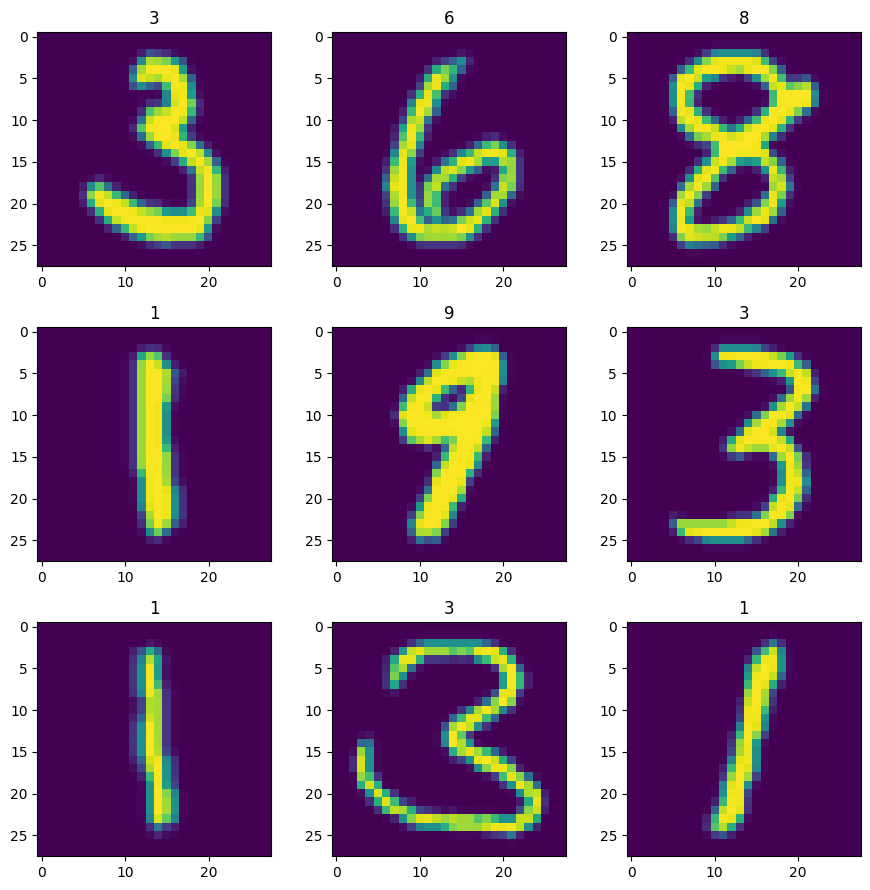

In [94]:
model_5.eval()
fig, axs = plt.subplots(3, 3, figsize=(9, 9))
axs = axs.ravel()  # or axs.flatten()

for i in range(9):
  random_idx = torch.randint(len(test_dataloader.dataset.targets), size=(1,1)).item()
  image  = test_dataloader.dataset.data[random_idx,:,:]
  axs[i].imshow(image.squeeze().T)

  X = image.unsqueeze(0).unsqueeze(0)
  X = X.to(torch.float32)

  with torch.inference_mode():
    label = model_5(X).argmax(dim=1).item()

  axs[i].set_title(label)

plt.tight_layout()
plt.show()

* # Confusion Matrix

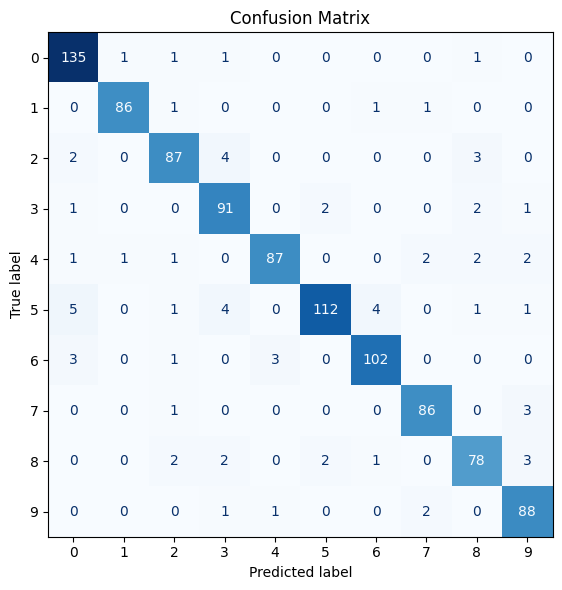

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_pred.flatten(), y_true.flatten())

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()